# Notebook 7 — Final Untouched Holdout Evaluation
## Frozen M15 vanilla volume-assisted CNN-LSTM

**Capstone:** *From Prediction to Profit: Designing, Deploying, and Benchmarking ML/DL Trading Bots for Live XAUUSD Paper-Trading*

This notebook performs the single final evaluation of the candidate selected in Notebook 6. It is not another model-selection notebook.

### Frozen candidate

- Model family: CNN-LSTM
- Track: vanilla volume-assisted
- Timeframe: M15
- Sequence length: 48 contiguous M15 bars
- Features: 51 relative/normalised features, including `volume_z20`

### Non-negotiable research rule

After the holdout result is generated, this notebook must not be used to change the architecture, feature definitions, threshold grid, risk rules, transaction-cost assumptions, or selected model family. A negative or no-trade result is a valid final result.


## Final chronology

| Role | Period | Permitted use |
|---|---|---|
| Inner model training | Before 1 January 2023 | Fit scaler and estimate model parameters |
| Inner model validation | Calendar year 2023 | Select the number of training epochs only |
| Final model training | All eligible observations before 1 January 2024 | Refit the frozen architecture and scaler |
| Overlay validation | Calendar year 2024 | Select one frozen overlay or stay flat |
| Final untouched holdout | 1 January 2025 to 31 March 2026 | Evaluate exactly once |

The CNN-LSTM architecture is already frozen by Notebook 6. No hyperparameter optimisation is conducted here.


## Methodological justification

The final holdout remains separate from every adaptive decision. This protects the final estimate from model-selection bias and repeated backtest searching. The 2023 inner validation period selects only the training epoch, while the 2024 outer validation period selects only the trading overlay. The 2025–March 2026 holdout is then evaluated after both are frozen.

The notebook uses contiguous sequence windows, causal Conv1D layers, and an LSTM configuration compatible with the fast cuDNN path when a suitable GPU is available. Early stopping monitors validation ROC-AUC and restores the best weights. Time-series uncertainty is summarised using a moving-block bootstrap of daily strategy returns rather than an IID bootstrap.

### Key references

- Cawley, G. C., and Talbot, N. L. C. (2010). *On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation*. JMLR, 11, 2079–2107.
- Bailey, D. H., Borwein, J. M., López de Prado, M., and Zhu, Q. J. (2015). *The Probability of Backtest Overfitting*.
- Künsch, H. R. (1989). *The Jackknife and the Bootstrap for General Stationary Observations*. Annals of Statistics, 17(3), 1217–1241.
- Politis, D. N. (2003). *The Impact of Bootstrap Methods on Time Series Analysis*. Statistical Science, 18(2), 219–230.
- TensorFlow documentation: `EarlyStopping`, causal `Conv1D`, and GPU-compatible `LSTM` requirements.


In [1]:
import importlib.util
import subprocess
import sys

for package_name, pip_name in [
    ('joblib', 'joblib'),
    ('pyarrow', 'pyarrow'),
    ('sklearn', 'scikit-learn'),
]:
    if importlib.util.find_spec(package_name) is None:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import shutil
import time
from pathlib import Path
from typing import Any

# Best-effort deterministic TensorFlow behaviour must be requested before model construction.
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ.setdefault('TF_CUDNN_DETERMINISTIC', '1')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print('Deterministic-op request warning:', exc)

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__ if hasattr(keras, '__version__') else 'bundled with TensorFlow')
print('scikit-learn:', __import__('sklearn').__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


Mounted at /content/drive
TensorFlow: 2.20.0
Keras: 3.13.2
scikit-learn: 1.6.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# =====================================
# Frozen Notebook 7 configuration
# =====================================

NOTEBOOK_CONFIG_VERSION = '07_final_holdout_v1_2026-06-17'
DEFAULT_PROJECT_ROOT = '/content/drive/MyDrive/fyp_master_starter' if IN_COLAB else str(Path('.').resolve())
PROJECT_ROOT = Path(os.environ.get('CAPSTONE_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'capstone_methodology'
PROCESSED_DIR = DATA_DIR / 'processed'
NOTEBOOK_OUTPUT_ROOT = DATA_DIR / 'notebook_outputs'

NB5_DIR = NOTEBOOK_OUTPUT_ROOT / '05_m15_cnn_lstm_walkforward_full'
NB6_DIR = NOTEBOOK_OUTPUT_ROOT / '06_m15_harmonised_cross_model_comparison'
OUTPUT_DIR = NOTEBOOK_OUTPUT_ROOT / '07_m15_cnn_lstm_final_holdout_evaluation'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
PREPROCESS_DIR = OUTPUT_DIR / 'preprocessing'
CONFIG_DIR = OUTPUT_DIR / 'configuration'
HISTORY_DIR = OUTPUT_DIR / 'training_histories'

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, PREPROCESS_DIR, CONFIG_DIR, HISTORY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASET_PATH = PROCESSED_DIR / 'dukascopy_xauusd_m15_volume_assisted_relative_dataset.parquet'
INTEGRITY_SUMMARY_PATH = DATA_DIR / 'reports' / 'data_quality' / 'dukascopy_xauusd_m5_m15_relative_pipeline_integrity_summary.json'
CANDIDATE_MANIFEST_PATH = NB6_DIR / 'configuration' / 'selected_candidate_manifest.json'
SELECTION_POLICY_PATH = NB6_DIR / 'configuration' / 'selection_policy.json'
NB5_RUN_CONFIG_PATH = NB5_DIR / 'configuration' / 'run_config.json'

INNER_TRAIN_END = pd.Timestamp('2023-01-01', tz='UTC')
INNER_VALIDATION_START = pd.Timestamp('2023-01-01', tz='UTC')
INNER_VALIDATION_END = pd.Timestamp('2024-01-01', tz='UTC')
FINAL_TRAIN_END = pd.Timestamp('2024-01-01', tz='UTC')
OVERLAY_VALIDATION_START = pd.Timestamp('2024-01-01', tz='UTC')
OVERLAY_VALIDATION_END = pd.Timestamp('2025-01-01', tz='UTC')
FINAL_HOLDOUT_START = pd.Timestamp('2025-01-01', tz='UTC')
FINAL_HOLDOUT_END_EXCLUSIVE = pd.Timestamp('2026-04-01', tz='UTC')

BAR_MINUTES = 15
EXPECTED_BAR_DELTA = pd.Timedelta(minutes=BAR_MINUTES)
CLASSIFICATION_THRESHOLD = 0.5
TARGET_COLUMNS = {'target_ret_fwd', 'target_dir', 'target_class_3'}
REQUIRE_GPU = True
ALLOW_CONFIG_MISMATCH = False
READ_ONLY_IF_COMPLETE = True

EXPECTED_CANDIDATE = {
    'model_family': 'CNN-LSTM',
    'model_family_key': 'cnn_lstm',
    'track': 'vanilla_volume_assisted',
    'feature_set': 'volume_assisted',
    'mode': 'vanilla',
}
EXPECTED_FROZEN_PARAMS = {
    'sequence_length': 48,
    'conv_filters_1': 32,
    'conv_filters_2': 0,
    'kernel_size': 3,
    'dilation_rate_2': 1,
    'pool_size': 2,
    'lstm_units': 64,
    'dropout': 0.20,
    'l2': 1e-5,
    'learning_rate': 1e-3,
    'batch_size': 1024,
    'max_epochs': 40,
    'patience': 6,
}

MAIN_SELECTION_COST_BPS = 1.0
COST_GRID_BPS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
THRESHOLD_GRID = [(0.51, 0.49), (0.52, 0.48), (0.53, 0.47), (0.55, 0.45)]
MIN_HOLD_GRID = [1, 2, 3]
MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID = [3, 5, 8]
DAILY_LOSS_STOP = -0.02
TOTAL_DRAWDOWN_STOP = -0.15
MIN_VALIDATION_TRADES = 20

BOOTSTRAP_REPLICATIONS = 2000
PRIMARY_BOOTSTRAP_BLOCK_DAYS = 5
BOOTSTRAP_BLOCK_SENSITIVITY = [5, 10, 20]

CONFIG_PATH = CONFIG_DIR / 'run_config.json'
COMPLETION_LOCK_PATH = CONFIG_DIR / 'holdout_evaluation_complete.json'
SELECTED_EPOCH_PATH = CONFIG_DIR / 'selected_epoch.json'
SELECTED_OVERLAY_PATH = CONFIG_DIR / 'selected_overlay.json'
FINAL_MODEL_PATH = MODEL_DIR / 'cnn_lstm_vanilla_volume_assisted_holdout_evaluation.keras'
FINAL_SCALER_PATH = PREPROCESS_DIR / 'cnn_lstm_vanilla_volume_assisted_holdout_scaler.pkl'
FINAL_FEATURES_PATH = PREPROCESS_DIR / 'cnn_lstm_vanilla_volume_assisted_holdout_features.json'
FINAL_PARAMS_PATH = PREPROCESS_DIR / 'cnn_lstm_vanilla_volume_assisted_holdout_params.json'
VALIDATION_PREDICTIONS_PATH = TABLE_DIR / 'overlay_validation_predictions.csv'
HOLDOUT_PREDICTIONS_PATH = TABLE_DIR / 'final_holdout_predictions.csv'

if REQUIRE_GPU and not tf.config.list_physical_devices('GPU'):
    raise RuntimeError('No GPU detected. Change the Colab runtime to GPU before executing Notebook 7.')

print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Existing completion lock:', COMPLETION_LOCK_PATH.exists())


Project root: /content/drive/MyDrive/fyp_master_starter
Output directory: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/07_m15_cnn_lstm_final_holdout_evaluation
Existing completion lock: False


In [4]:
def json_ready(value: Any) -> Any:
    if isinstance(value, (pd.Timestamp, Path, pd.Timedelta)):
        return str(value)
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def atomic_write_json(path: Path, payload: dict[str, Any]) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_text(json.dumps(json_ready(payload), indent=2), encoding='utf-8')
    tmp.replace(path)


def atomic_dump_joblib(obj: Any, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    joblib.dump(obj, tmp)
    tmp.replace(path)


def atomic_write_csv(frame: pd.DataFrame, path: Path, index: bool = False) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    frame.to_csv(tmp, index=index)
    tmp.replace(path)


def atomic_save_keras(model: keras.Model, path: Path) -> None:
    tmp = path.with_name(path.stem + '.tmp.keras')
    if tmp.exists():
        tmp.unlink()
    model.save(tmp)
    tmp.replace(path)


critical_config = {
    'notebook_config_version': NOTEBOOK_CONFIG_VERSION,
    'expected_candidate': EXPECTED_CANDIDATE,
    'expected_frozen_params': EXPECTED_FROZEN_PARAMS,
    'inner_train_end': INNER_TRAIN_END,
    'inner_validation_start': INNER_VALIDATION_START,
    'inner_validation_end': INNER_VALIDATION_END,
    'final_train_end': FINAL_TRAIN_END,
    'overlay_validation_start': OVERLAY_VALIDATION_START,
    'overlay_validation_end': OVERLAY_VALIDATION_END,
    'final_holdout_start': FINAL_HOLDOUT_START,
    'final_holdout_end_exclusive': FINAL_HOLDOUT_END_EXCLUSIVE,
    'main_selection_cost_bps': MAIN_SELECTION_COST_BPS,
    'cost_grid_bps': COST_GRID_BPS,
    'threshold_grid': THRESHOLD_GRID,
    'min_hold_grid': MIN_HOLD_GRID,
    'max_position_change_events_per_day_grid': MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID,
    'daily_loss_stop': DAILY_LOSS_STOP,
    'total_drawdown_stop': TOTAL_DRAWDOWN_STOP,
    'min_validation_trades': MIN_VALIDATION_TRADES,
    'bootstrap_replications': BOOTSTRAP_REPLICATIONS,
    'primary_bootstrap_block_days': PRIMARY_BOOTSTRAP_BLOCK_DAYS,
    'bootstrap_block_sensitivity': BOOTSTRAP_BLOCK_SENSITIVITY,
}
config_payload = json.dumps(json_ready(critical_config), sort_keys=True, indent=2)
config_fingerprint = hashlib.sha256(config_payload.encode('utf-8')).hexdigest()

if CONFIG_PATH.exists():
    saved_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    if saved_config.get('config_fingerprint') != config_fingerprint and not ALLOW_CONFIG_MISMATCH:
        raise RuntimeError(
            'Notebook 7 configuration mismatch. Do not rerun the final holdout with changed settings. '
            'Use the original notebook and output directory.'
        )
else:
    atomic_write_json(CONFIG_PATH, {
        'config_fingerprint': config_fingerprint,
        'critical_config': critical_config,
    })

READ_ONLY_COMPLETE = COMPLETION_LOCK_PATH.exists() and READ_ONLY_IF_COMPLETE
print('Configuration fingerprint:', config_fingerprint)
print('Read-only completed mode:', READ_ONLY_COMPLETE)


Configuration fingerprint: 55b349c6d957d26e528c0546c78fb7363bf515a93ce705c6a4c0e97862aff326
Read-only completed mode: False


## Candidate and artefact freeze audit

This section verifies that Notebook 7 is using the exact model family, track, architecture, feature order, overlay grid, cost grid, and risk controls selected before the holdout was opened.


In [5]:
for required_path in [
    CANDIDATE_MANIFEST_PATH,
    SELECTION_POLICY_PATH,
    NB5_RUN_CONFIG_PATH,
    INTEGRITY_SUMMARY_PATH,
    DATASET_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing required artefact: {required_path}')

candidate_manifest = json.loads(CANDIDATE_MANIFEST_PATH.read_text(encoding='utf-8'))
selection_policy = json.loads(SELECTION_POLICY_PATH.read_text(encoding='utf-8'))
nb5_run_config = json.loads(NB5_RUN_CONFIG_PATH.read_text(encoding='utf-8'))
integrity_summary = json.loads(INTEGRITY_SUMMARY_PATH.read_text(encoding='utf-8'))

if integrity_summary.get('final_status') != 'PASS':
    raise RuntimeError(f'Data pipeline integrity is not PASS: {integrity_summary}')

candidate_mismatches = {
    key: (candidate_manifest.get(key), expected)
    for key, expected in EXPECTED_CANDIDATE.items()
    if candidate_manifest.get(key) != expected
}
if candidate_mismatches:
    raise RuntimeError(f'Notebook 6 candidate manifest mismatch: {candidate_mismatches}')
if candidate_manifest.get('final_holdout_status') != 'untouched':
    raise RuntimeError('Notebook 6 does not mark the holdout as untouched.')

# Verify that all three development-fold vanilla candidate parameter and feature files agree.
param_files = sorted((NB5_DIR / 'preprocessing').glob('vanilla_volume_assisted_fold*_params.json'))
feature_files = sorted((NB5_DIR / 'preprocessing').glob('vanilla_volume_assisted_fold*_features.json'))
if len(param_files) != 3 or len(feature_files) != 3:
    raise RuntimeError('Expected exactly three vanilla volume-assisted parameter and feature files from Notebook 5.')

loaded_params = [json.loads(path.read_text(encoding='utf-8'))['selected_params'] for path in param_files]
if any(params != loaded_params[0] for params in loaded_params[1:]):
    raise RuntimeError('Notebook 5 vanilla volume-assisted parameters differ across folds.')
if loaded_params[0] != EXPECTED_FROZEN_PARAMS:
    raise RuntimeError(f'Frozen architecture mismatch: {loaded_params[0]}')

loaded_features = [json.loads(path.read_text(encoding='utf-8')) for path in feature_files]
if any(features != loaded_features[0] for features in loaded_features[1:]):
    raise RuntimeError('Notebook 5 vanilla volume-assisted feature order differs across folds.')
FROZEN_FEATURES = loaded_features[0]
if len(FROZEN_FEATURES) != 51 or 'volume_z20' not in FROZEN_FEATURES:
    raise RuntimeError('Frozen volume-assisted feature list is not the expected 51-feature list.')

nb5_critical = nb5_run_config['critical_config']
policy_checks = {
    'vanilla_params': nb5_critical['vanilla_params'] == EXPECTED_FROZEN_PARAMS,
    'main_selection_cost_bps': float(nb5_critical['main_selection_cost_bps']) == MAIN_SELECTION_COST_BPS,
    'cost_grid_bps': list(nb5_critical['cost_grid_bps']) == COST_GRID_BPS,
    'threshold_grid': [tuple(v) for v in nb5_critical['threshold_grid']] == THRESHOLD_GRID,
    'min_hold_grid': list(nb5_critical['min_hold_grid']) == MIN_HOLD_GRID,
    'max_position_change_grid': list(nb5_critical['max_position_change_events_per_day_grid']) == MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID,
    'daily_loss_stop': float(nb5_critical['daily_loss_stop']) == DAILY_LOSS_STOP,
    'total_drawdown_stop': float(nb5_critical['total_drawdown_stop']) == TOTAL_DRAWDOWN_STOP,
    'min_validation_trades': int(nb5_critical['min_validation_trades']) == MIN_VALIDATION_TRADES,
}
if not all(policy_checks.values()):
    raise RuntimeError(f'Notebook 5 policy parity failed: {policy_checks}')

freeze_audit = pd.DataFrame([
    {'check': 'Notebook 6 selected candidate', 'passed': not candidate_mismatches},
    {'check': 'Notebook 6 holdout status untouched', 'passed': candidate_manifest.get('final_holdout_status') == 'untouched'},
    {'check': 'Notebook 5 architecture identical across folds', 'passed': all(p == loaded_params[0] for p in loaded_params)},
    {'check': 'Frozen architecture matches expected', 'passed': loaded_params[0] == EXPECTED_FROZEN_PARAMS},
    {'check': 'Feature order identical across folds', 'passed': all(f == loaded_features[0] for f in loaded_features)},
    {'check': '51 volume-assisted features', 'passed': len(FROZEN_FEATURES) == 51 and 'volume_z20' in FROZEN_FEATURES},
    *[{'check': f'Policy parity: {key}', 'passed': value} for key, value in policy_checks.items()],
])
freeze_audit.to_csv(TABLE_DIR / 'candidate_freeze_audit.csv', index=False)
display(freeze_audit)
if not freeze_audit['passed'].all():
    raise RuntimeError('Candidate freeze audit failed.')

atomic_write_json(CONFIG_DIR / 'candidate_manifest_copy.json', candidate_manifest)
atomic_write_json(CONFIG_DIR / 'selection_policy_copy.json', selection_policy)
print('Frozen candidate and policy verified.')


,check,passed
0,Notebook 6 selected candidate,True
1,Notebook 6 holdout status untouched,True
2,Notebook 5 architecture identical across folds,True
3,Frozen architecture matches expected,True
4,Feature order identical across folds,True
5,51 volume-assisted features,True
6,Policy parity: vanilla_params,True
7,Policy parity: main_selection_cost_bps,True
8,Policy parity: cost_grid_bps,True
9,Policy parity: threshold_grid,True


Frozen candidate and policy verified.


In [6]:
def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'time' not in df.columns:
            raise ValueError('Dataset has no DatetimeIndex or time column.')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.set_index('time')
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = 'time'
    return df.sort_index()


dataset = load_dataset(DATASET_PATH)
missing_features = [feature for feature in FROZEN_FEATURES if feature not in dataset.columns]
if missing_features:
    raise ValueError(f'Missing frozen features: {missing_features}')
for target_col in ['target_dir', 'target_ret_fwd']:
    if target_col not in dataset.columns:
        raise ValueError(f'Missing target column: {target_col}')

if dataset.index.duplicated().any():
    raise ValueError('Dataset index contains duplicates.')
if dataset[FROZEN_FEATURES + ['target_dir', 'target_ret_fwd']].isna().any().any():
    raise ValueError('Dataset contains missing model inputs or targets.')
if not np.isfinite(dataset[FROZEN_FEATURES + ['target_ret_fwd']].to_numpy(dtype=float)).all():
    raise ValueError('Dataset contains non-finite model inputs or returns.')

inner_train_df = dataset.loc[dataset.index < INNER_TRAIN_END].copy()
inner_validation_df = dataset.loc[
    (dataset.index >= INNER_VALIDATION_START) & (dataset.index < INNER_VALIDATION_END)
].copy()
final_train_df = dataset.loc[dataset.index < FINAL_TRAIN_END].copy()
overlay_validation_df = dataset.loc[
    (dataset.index >= OVERLAY_VALIDATION_START) & (dataset.index < OVERLAY_VALIDATION_END)
].copy()

# The holdout slice is defined here for row-count auditing only. It is not predicted until the overlay is frozen.
holdout_row_audit_df = dataset.loc[
    (dataset.index >= FINAL_HOLDOUT_START) & (dataset.index < FINAL_HOLDOUT_END_EXCLUSIVE)
].copy()

if min(len(inner_train_df), len(inner_validation_df), len(final_train_df), len(overlay_validation_df), len(holdout_row_audit_df)) == 0:
    raise RuntimeError('At least one final temporal partition is empty.')

partition_rows = pd.DataFrame([
    {'role': 'inner_train', 'start': inner_train_df.index.min(), 'end': inner_train_df.index.max(), 'rows': len(inner_train_df)},
    {'role': 'inner_validation', 'start': inner_validation_df.index.min(), 'end': inner_validation_df.index.max(), 'rows': len(inner_validation_df)},
    {'role': 'final_train', 'start': final_train_df.index.min(), 'end': final_train_df.index.max(), 'rows': len(final_train_df)},
    {'role': 'overlay_validation', 'start': overlay_validation_df.index.min(), 'end': overlay_validation_df.index.max(), 'rows': len(overlay_validation_df)},
    {'role': 'final_holdout', 'start': holdout_row_audit_df.index.min(), 'end': holdout_row_audit_df.index.max(), 'rows': len(holdout_row_audit_df)},
])
partition_rows.to_csv(TABLE_DIR / 'final_temporal_partition_rows.csv', index=False)
display(partition_rows)
print('Dataset range:', dataset.index.min(), 'to', dataset.index.max())
print('Holdout remains unused for selection:', FINAL_HOLDOUT_START, 'to', FINAL_HOLDOUT_END_EXCLUSIVE)


,role,start,end,rows
0,inner_train,2016-01-06 03:15:00+00:00,2022-12-30 21:30:00+00:00,161599
1,inner_validation,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,22985
2,final_train,2016-01-06 03:15:00+00:00,2023-12-29 21:30:00+00:00,184584
3,overlay_validation,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00,23382
4,final_holdout,2025-01-01 23:15:00+00:00,2026-03-31 23:45:00+00:00,29035


Dataset range: 2016-01-06 03:15:00+00:00 to 2026-03-31 23:45:00+00:00
Holdout remains unused for selection: 2025-01-01 00:00:00+00:00 to 2026-04-01 00:00:00+00:00


## Core modelling and evaluation functions

These functions preserve the final Notebook 5 sequence, model, overlay, transaction-cost, and risk-control behaviour. The detailed simulator additionally records every bar and position-change event for audit and reporting.


In [7]:
def valid_sequence_positions(index: pd.DatetimeIndex, sequence_length: int) -> tuple[np.ndarray, np.ndarray]:
    index = pd.DatetimeIndex(index)
    if len(index) < sequence_length:
        return np.array([], dtype=np.int64), np.array([], dtype=np.int64)
    gap_flags = np.zeros(len(index), dtype=np.int64)
    deltas_ns = index.asi8[1:] - index.asi8[:-1]
    gap_flags[1:] = (deltas_ns != EXPECTED_BAR_DELTA.value).astype(np.int64)
    gap_cumsum = np.cumsum(gap_flags)
    starts = np.arange(0, len(index) - sequence_length + 1, dtype=np.int64)
    ends = starts + sequence_length - 1
    gaps_inside = gap_cumsum[ends] - gap_cumsum[starts]
    valid = gaps_inside == 0
    return starts[valid], ends[valid]


def make_sequence_dataset(
    X: np.ndarray,
    y: np.ndarray | None,
    starts: np.ndarray,
    sequence_length: int,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> tf.data.Dataset:
    if len(starts) == 0:
        raise ValueError(f'No valid contiguous sequences for sequence_length={sequence_length}.')
    X_tensor = tf.convert_to_tensor(X.astype('float32'))
    y_tensor = None if y is None else tf.convert_to_tensor(y.astype('float32'))
    ds = tf.data.Dataset.from_tensor_slices(starts.astype(np.int64))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(starts), 100_000), seed=seed, reshuffle_each_iteration=True)

    if y_tensor is None:
        def extract(start):
            start = tf.cast(start, tf.int32)
            return X_tensor[start:start + sequence_length]
    else:
        def extract(start):
            start = tf.cast(start, tf.int32)
            return X_tensor[start:start + sequence_length], y_tensor[start + sequence_length - 1]

    ds = ds.map(extract, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    options = tf.data.Options()
    options.experimental_deterministic = not shuffle
    return ds.with_options(options).prefetch(tf.data.AUTOTUNE)


def build_cnn_lstm_model(n_features: int, params: dict[str, Any]) -> keras.Model:
    reg = regularizers.l2(float(params['l2'])) if float(params['l2']) > 0 else None
    inputs = keras.Input(
        shape=(int(params['sequence_length']), n_features),
        name='m15_relative_feature_sequence',
    )
    x = layers.Conv1D(
        filters=int(params['conv_filters_1']),
        kernel_size=int(params['kernel_size']),
        padding='causal',
        dilation_rate=1,
        activation='relu',
        kernel_regularizer=reg,
        name='causal_conv_1',
    )(inputs)
    x = layers.SpatialDropout1D(float(params['dropout']), name='spatial_dropout_1')(x)
    if int(params.get('conv_filters_2', 0)) > 0:
        x = layers.Conv1D(
            filters=int(params['conv_filters_2']),
            kernel_size=int(params['kernel_size']),
            padding='causal',
            dilation_rate=int(params.get('dilation_rate_2', 1)),
            activation='relu',
            kernel_regularizer=reg,
            name='causal_conv_2',
        )(x)
        x = layers.SpatialDropout1D(float(params['dropout']), name='spatial_dropout_2')(x)
    if int(params.get('pool_size', 1)) > 1:
        x = layers.MaxPooling1D(pool_size=int(params['pool_size']), name='temporal_pool')(x)
    x = layers.LSTM(
        int(params['lstm_units']),
        return_sequences=False,
        kernel_regularizer=reg,
        dropout=0.0,
        recurrent_dropout=0.0,
        name='temporal_lstm',
    )(x)
    x = layers.Dropout(float(params['dropout']), name='post_lstm_dropout')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='p_up')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='m15_cnn_lstm_final_holdout')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=float(params['learning_rate'])),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.BinaryAccuracy(name='accuracy')],
    )
    return model


def classification_metrics(y_true: np.ndarray, p_up: np.ndarray, baseline_p: float) -> dict[str, float]:
    y_pred = (p_up >= CLASSIFICATION_THRESHOLD).astype(int)
    clipped = np.clip(p_up, 1e-6, 1 - 1e-6)
    baseline_probs = np.full(len(y_true), np.clip(baseline_p, 1e-6, 1 - 1e-6), dtype=float)
    metrics = {
        'roc_auc': float(roc_auc_score(y_true, p_up)) if len(np.unique(y_true)) == 2 else np.nan,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'brier': float(brier_score_loss(y_true, p_up)),
        'baseline_brier': float(brier_score_loss(y_true, baseline_probs)),
        'log_loss': float(log_loss(y_true, clipped)),
        'baseline_log_loss': float(log_loss(y_true, baseline_probs)),
        'positive_rate': float(np.mean(y_true)),
        'predicted_positive_rate': float(np.mean(y_pred)),
    }
    metrics['brier_improvement_vs_baseline'] = metrics['baseline_brier'] - metrics['brier']
    metrics['log_loss_improvement_vs_baseline'] = metrics['baseline_log_loss'] - metrics['log_loss']
    return metrics


def max_drawdown_from_log_returns(log_returns: np.ndarray) -> float:
    if len(log_returns) == 0:
        return 0.0
    equity = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(equity)
    drawdown = equity / peak - 1.0
    return float(drawdown.min()) if len(drawdown) else 0.0


def sortino_ratio(log_returns: np.ndarray, periods_per_year: float) -> float:
    if len(log_returns) < 2:
        return 0.0
    downside = log_returns[log_returns < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return 0.0
    return float(log_returns.mean() / downside.std(ddof=1) * math.sqrt(periods_per_year))


def profit_factor(log_returns: np.ndarray) -> float:
    gains = log_returns[log_returns > 0].sum()
    losses = -log_returns[log_returns < 0].sum()
    if losses == 0:
        return float('inf') if gains > 0 else 0.0
    return float(gains / losses)


def simulate_signal_overlay(
    timestamps: pd.DatetimeIndex,
    p_up: np.ndarray,
    forward_log_returns: np.ndarray,
    upper_threshold: float,
    lower_threshold: float,
    min_hold_bars: int,
    max_position_change_events_per_day: int,
    cost_bps: float,
) -> tuple[dict[str, Any], pd.DataFrame]:
    timestamps = pd.DatetimeIndex(timestamps)
    desired = np.where(p_up >= upper_threshold, 1, np.where(p_up <= lower_threshold, -1, 0)).astype(int)

    positions = np.zeros(len(desired), dtype=int)
    gross_log_returns = np.zeros(len(desired), dtype=float)
    net_log_returns = np.zeros(len(desired), dtype=float)
    costs = np.zeros(len(desired), dtype=float)
    turnover_arr = np.zeros(len(desired), dtype=float)
    gap_arr = np.zeros(len(desired), dtype=bool)
    daily_stop_arr = np.zeros(len(desired), dtype=bool)
    total_stop_arr = np.zeros(len(desired), dtype=bool)

    position_change_events = 0
    turnover_units = 0.0
    trades = 0
    stopped_by_total_dd = False
    daily_stop_active = False
    current_day = None
    daily_log_sum = 0.0
    bars_since_change = 10**9
    prev_pos = 0
    equity_log = 0.0
    peak_equity = 1.0
    total_dd_stop_triggered = False
    daily_loss_stop_triggered_count = 0

    for i, ts in enumerate(timestamps):
        day = ts.date()
        if current_day != day:
            current_day = day
            daily_log_sum = 0.0
            daily_stop_active = False
            day_position_change_events = 0

        is_gap = i > 0 and (timestamps[i] - timestamps[i - 1]) != EXPECTED_BAR_DELTA
        gap_arr[i] = is_gap

        if stopped_by_total_dd:
            new_pos = 0
        elif is_gap:
            new_pos = 0
            bars_since_change = 10**9
        elif daily_stop_active:
            new_pos = 0
        else:
            proposed = desired[i]
            can_change_due_to_hold = bars_since_change >= min_hold_bars
            if proposed != prev_pos and can_change_due_to_hold:
                if day_position_change_events < max_position_change_events_per_day:
                    new_pos = proposed
                    day_position_change_events += 1
                    position_change_events += 1
                    bars_since_change = 0
                else:
                    new_pos = prev_pos
            else:
                new_pos = prev_pos

        turnover = abs(new_pos - prev_pos)
        cost = (cost_bps / 10000.0) * turnover
        gross = new_pos * forward_log_returns[i]
        net = gross - cost

        positions[i] = new_pos
        turnover_arr[i] = turnover
        costs[i] = cost
        gross_log_returns[i] = gross
        net_log_returns[i] = net
        turnover_units += turnover
        if turnover > 0 and new_pos != 0:
            trades += 1

        equity_log += net
        equity = math.exp(equity_log)
        peak_equity = max(peak_equity, equity)
        drawdown = equity / peak_equity - 1.0
        daily_log_sum += net

        if daily_log_sum <= math.log(1 + DAILY_LOSS_STOP) and not daily_stop_active:
            daily_stop_active = True
            daily_loss_stop_triggered_count += 1

        if drawdown <= TOTAL_DRAWDOWN_STOP and not stopped_by_total_dd:
            stopped_by_total_dd = True
            total_dd_stop_triggered = True

        daily_stop_arr[i] = daily_stop_active
        total_stop_arr[i] = stopped_by_total_dd

        if new_pos == prev_pos:
            bars_since_change += 1
        prev_pos = new_pos

    periods_per_year = (24 * 60 / BAR_MINUTES) * 252
    total_net_return = float(math.exp(net_log_returns.sum()) - 1.0)
    total_gross_return = float(math.exp(gross_log_returns.sum()) - 1.0)
    mean_ret = net_log_returns.mean() if len(net_log_returns) else 0.0
    std_ret = net_log_returns.std(ddof=1) if len(net_log_returns) > 1 else 0.0
    sharpe = float(mean_ret / std_ret * math.sqrt(periods_per_year)) if std_ret > 0 else 0.0
    metrics = {
        'net_return': total_net_return,
        'gross_return': total_gross_return,
        'sharpe': sharpe,
        'sortino': sortino_ratio(net_log_returns, periods_per_year),
        'max_drawdown': max_drawdown_from_log_returns(net_log_returns),
        'turnover_units': float(turnover_units),
        'turnover_units_per_day': float(turnover_units / max((timestamps.max() - timestamps.min()).days, 1)),
        'position_change_events': int(position_change_events),
        'position_change_events_per_day': float(position_change_events / max((timestamps.max() - timestamps.min()).days, 1)),
        'trade_count': int(trades),
        'active_rate': float(np.mean(positions != 0)) if len(positions) else 0.0,
        'win_rate': float(np.mean(net_log_returns[net_log_returns != 0] > 0)) if np.any(net_log_returns != 0) else 0.0,
        'profit_factor': profit_factor(net_log_returns),
        'daily_loss_stop_triggered_count': int(daily_loss_stop_triggered_count),
        'total_drawdown_stop_triggered': bool(total_dd_stop_triggered),
    }

    bar_log = pd.DataFrame({
        'time': timestamps,
        'p_up': p_up,
        'desired_position': desired,
        'position': positions,
        'turnover_units': turnover_arr,
        'gross_log_return': gross_log_returns,
        'cost_log_return': costs,
        'net_log_return': net_log_returns,
        'gross_equity': np.exp(np.cumsum(gross_log_returns)),
        'net_equity': np.exp(np.cumsum(net_log_returns)),
        'drawdown': np.exp(np.cumsum(net_log_returns)) / np.maximum.accumulate(np.exp(np.cumsum(net_log_returns))) - 1.0,
        'is_gap': gap_arr,
        'daily_stop_active': daily_stop_arr,
        'total_drawdown_stop_active': total_stop_arr,
    })
    return metrics, bar_log


def evaluate_overlay_grid(timestamps: pd.DatetimeIndex, p_up: np.ndarray, returns: np.ndarray) -> pd.DataFrame:
    rows = []
    for upper, lower in THRESHOLD_GRID:
        for min_hold in MIN_HOLD_GRID:
            for max_changes in MAX_POSITION_CHANGE_EVENTS_PER_DAY_GRID:
                metrics, _ = simulate_signal_overlay(
                    timestamps=timestamps,
                    p_up=p_up,
                    forward_log_returns=returns,
                    upper_threshold=upper,
                    lower_threshold=lower,
                    min_hold_bars=min_hold,
                    max_position_change_events_per_day=max_changes,
                    cost_bps=MAIN_SELECTION_COST_BPS,
                )
                rows.append({
                    'upper_threshold': upper,
                    'lower_threshold': lower,
                    'min_hold_bars': min_hold,
                    'max_position_change_events_per_day': max_changes,
                    **metrics,
                })
    return pd.DataFrame(rows)


def select_overlay(validation_grid: pd.DataFrame) -> dict[str, Any]:
    candidates = validation_grid.copy()
    candidates['is_viable'] = (
        (candidates['net_return'] > 0)
        & (candidates['trade_count'] >= MIN_VALIDATION_TRADES)
        & (candidates['max_drawdown'] > TOTAL_DRAWDOWN_STOP)
    )
    viable = candidates[candidates['is_viable']].copy()
    if viable.empty:
        return {
            'selected_action': 'stay_flat',
            'upper_threshold': np.nan,
            'lower_threshold': np.nan,
            'min_hold_bars': np.nan,
            'max_position_change_events_per_day': np.nan,
            'validation_selected_net_return': 0.0,
            'validation_selected_sharpe': 0.0,
            'validation_selected_max_drawdown': 0.0,
            'validation_selected_trade_count': 0,
            'validation_selected_active_rate': 0.0,
            'validation_viable_candidates': 0,
        }
    viable = viable.sort_values(
        by=['net_return', 'sharpe', 'max_drawdown', 'turnover_units_per_day'],
        ascending=[False, False, False, True],
    )
    best = viable.iloc[0]
    return {
        'selected_action': 'trade',
        'upper_threshold': float(best['upper_threshold']),
        'lower_threshold': float(best['lower_threshold']),
        'min_hold_bars': int(best['min_hold_bars']),
        'max_position_change_events_per_day': int(best['max_position_change_events_per_day']),
        'validation_selected_net_return': float(best['net_return']),
        'validation_selected_sharpe': float(best['sharpe']),
        'validation_selected_max_drawdown': float(best['max_drawdown']),
        'validation_selected_trade_count': int(best['trade_count']),
        'validation_selected_active_rate': float(best['active_rate']),
        'validation_viable_candidates': int(len(viable)),
    }


def evaluate_selected_overlay(
    timestamps: pd.DatetimeIndex,
    p_up: np.ndarray,
    returns: np.ndarray,
    selected: dict[str, Any],
    cost_bps: float,
) -> tuple[dict[str, Any], pd.DataFrame]:
    if selected['selected_action'] == 'stay_flat':
        empty_log = pd.DataFrame({
            'time': timestamps,
            'p_up': p_up,
            'desired_position': np.zeros(len(timestamps), dtype=int),
            'position': np.zeros(len(timestamps), dtype=int),
            'turnover_units': np.zeros(len(timestamps)),
            'gross_log_return': np.zeros(len(timestamps)),
            'cost_log_return': np.zeros(len(timestamps)),
            'net_log_return': np.zeros(len(timestamps)),
            'gross_equity': np.ones(len(timestamps)),
            'net_equity': np.ones(len(timestamps)),
            'drawdown': np.zeros(len(timestamps)),
            'is_gap': np.zeros(len(timestamps), dtype=bool),
            'daily_stop_active': np.zeros(len(timestamps), dtype=bool),
            'total_drawdown_stop_active': np.zeros(len(timestamps), dtype=bool),
        })
        return {
            'net_return': 0.0,
            'gross_return': 0.0,
            'sharpe': 0.0,
            'sortino': 0.0,
            'max_drawdown': 0.0,
            'turnover_units': 0.0,
            'turnover_units_per_day': 0.0,
            'position_change_events': 0,
            'position_change_events_per_day': 0.0,
            'trade_count': 0,
            'active_rate': 0.0,
            'win_rate': 0.0,
            'profit_factor': 0.0,
            'daily_loss_stop_triggered_count': 0,
            'total_drawdown_stop_triggered': False,
        }, empty_log
    return simulate_signal_overlay(
        timestamps=timestamps,
        p_up=p_up,
        forward_log_returns=returns,
        upper_threshold=float(selected['upper_threshold']),
        lower_threshold=float(selected['lower_threshold']),
        min_hold_bars=int(selected['min_hold_bars']),
        max_position_change_events_per_day=int(selected['max_position_change_events_per_day']),
        cost_bps=cost_bps,
    )


def fit_scaler(fit_df: pd.DataFrame) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(fit_df[FROZEN_FEATURES].astype('float32'))
    return scaler


def transform_frame(scaler: StandardScaler, frame: pd.DataFrame) -> np.ndarray:
    return scaler.transform(frame[FROZEN_FEATURES].astype('float32')).astype('float32')


def make_callbacks(patience: int) -> list[keras.callbacks.Callback]:
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=int(patience),
            min_delta=1e-4,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=max(2, int(patience) // 2),
            min_lr=1e-6,
        ),
        keras.callbacks.TerminateOnNaN(),
    ]


def predict_aligned(
    model: keras.Model,
    scaler: StandardScaler,
    frame: pd.DataFrame,
    seed: int,
) -> pd.DataFrame:
    X = transform_frame(scaler, frame)
    y = frame['target_dir'].astype(int).to_numpy()
    sequence_length = int(EXPECTED_FROZEN_PARAMS['sequence_length'])
    starts, ends = valid_sequence_positions(frame.index, sequence_length)
    ds = make_sequence_dataset(
        X=X,
        y=None,
        starts=starts,
        sequence_length=sequence_length,
        batch_size=int(EXPECTED_FROZEN_PARAMS['batch_size']),
        shuffle=False,
        seed=seed,
    )
    probs = model.predict(ds, verbose=0).reshape(-1)
    aligned = frame.iloc[ends][['target_dir', 'target_ret_fwd']].copy()
    aligned['p_up'] = probs
    aligned['target_dir'] = aligned['target_dir'].astype(int)
    aligned.index.name = 'time'
    return aligned.reset_index()


def circular_moving_block_bootstrap(
    daily_log_returns: np.ndarray,
    block_length: int,
    n_replications: int,
    seed: int,
) -> pd.DataFrame:
    arr = np.asarray(daily_log_returns, dtype=float)
    n = len(arr)
    if n == 0:
        return pd.DataFrame(columns=['replication', 'total_return', 'annualized_sharpe', 'max_drawdown'])
    rng = np.random.default_rng(seed)
    n_blocks = int(math.ceil(n / block_length))
    rows = []
    for rep in range(n_replications):
        starts = rng.integers(0, n, size=n_blocks)
        sampled = np.concatenate([
            arr[(np.arange(start, start + block_length) % n)] for start in starts
        ])[:n]
        std = sampled.std(ddof=1) if len(sampled) > 1 else 0.0
        sharpe = float(sampled.mean() / std * math.sqrt(252)) if std > 0 else 0.0
        rows.append({
            'replication': rep,
            'total_return': float(math.exp(sampled.sum()) - 1.0),
            'annualized_sharpe': sharpe,
            'max_drawdown': max_drawdown_from_log_returns(sampled),
        })
    return pd.DataFrame(rows)


## Stage 1 — Select the final training epoch using 2023 only

The architecture remains frozen. The only adaptive model decision in Notebook 7 is the number of epochs, selected from the 2023 inner validation period. The holdout is not accessed.


In [8]:
if SELECTED_EPOCH_PATH.exists():
    epoch_payload = json.loads(SELECTED_EPOCH_PATH.read_text(encoding='utf-8'))
    selected_epoch = int(epoch_payload['selected_epoch'])
    print('Loaded previously selected epoch:', selected_epoch)
else:
    if READ_ONLY_COMPLETE:
        raise RuntimeError('Completed holdout lock exists but selected-epoch artefact is missing.')

    inner_scaler = fit_scaler(inner_train_df)
    X_inner_train = transform_frame(inner_scaler, inner_train_df)
    X_inner_validation = transform_frame(inner_scaler, inner_validation_df)
    y_inner_train = inner_train_df['target_dir'].astype(int).to_numpy()
    y_inner_validation = inner_validation_df['target_dir'].astype(int).to_numpy()

    sequence_length = int(EXPECTED_FROZEN_PARAMS['sequence_length'])
    train_starts, _ = valid_sequence_positions(inner_train_df.index, sequence_length)
    validation_starts, validation_ends = valid_sequence_positions(inner_validation_df.index, sequence_length)
    train_ds = make_sequence_dataset(
        X_inner_train, y_inner_train, train_starts, sequence_length,
        int(EXPECTED_FROZEN_PARAMS['batch_size']), True, SEED,
    )
    validation_ds = make_sequence_dataset(
        X_inner_validation, y_inner_validation, validation_starts, sequence_length,
        int(EXPECTED_FROZEN_PARAMS['batch_size']), False, SEED,
    )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    inner_model = build_cnn_lstm_model(len(FROZEN_FEATURES), EXPECTED_FROZEN_PARAMS)
    start_time = time.time()
    history = inner_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=int(EXPECTED_FROZEN_PARAMS['max_epochs']),
        callbacks=make_callbacks(int(EXPECTED_FROZEN_PARAMS['patience'])),
        verbose=1,
    )
    elapsed = time.time() - start_time
    inner_history = pd.DataFrame(history.history)
    inner_history['epoch'] = np.arange(1, len(inner_history) + 1)
    if inner_history.empty or 'val_auc' not in inner_history:
        raise RuntimeError('Inner epoch-selection training produced no validation AUC history.')
    best_idx = int(inner_history['val_auc'].astype(float).idxmax())
    selected_epoch = int(inner_history.loc[best_idx, 'epoch'])

    validation_probs = inner_model.predict(validation_ds, verbose=0).reshape(-1)
    validation_y = y_inner_validation[validation_ends]
    epoch_payload = {
        'selected_epoch': selected_epoch,
        'epochs_trained_before_early_stop': int(len(inner_history)),
        'best_inner_validation_auc': float(roc_auc_score(validation_y, validation_probs)),
        'best_inner_validation_brier': float(brier_score_loss(validation_y, validation_probs)),
        'training_seconds': float(elapsed),
        'inner_train_sequences': int(len(train_starts)),
        'inner_validation_sequences': int(len(validation_starts)),
        'seed': SEED,
    }
    inner_history.to_csv(HISTORY_DIR / 'inner_epoch_selection_history.csv', index=False)
    atomic_write_json(SELECTED_EPOCH_PATH, epoch_payload)
    del inner_model, inner_scaler, train_ds, validation_ds
    tf.keras.backend.clear_session()
    gc.collect()

print('Frozen final training epoch:', selected_epoch)
display(pd.DataFrame([json.loads(SELECTED_EPOCH_PATH.read_text(encoding='utf-8'))]))


Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.5060 - auc: 0.5075 - loss: 0.6978 - val_accuracy: 0.5079 - val_auc: 0.5142 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.5145 - auc: 0.5185 - loss: 0.6941 - val_accuracy: 0.5126 - val_auc: 0.5198 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.5175 - auc: 0.5244 - loss: 0.6932 - val_accuracy: 0.5162 - val_auc: 0.5231 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.5207 - auc: 0.5287 - loss: 0.6928 - val_accuracy: 0.5188 - val_auc: 0.5288 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5212 - auc: 0.5311 - loss: 0.6926 - val_accuracy: 0.5139 - val_auc: 0.5229 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.5247 - auc: 0.534

,selected_epoch,epochs_trained_before_early_stop,best_inner_validation_auc,best_inner_validation_brier,training_seconds,inner_train_sequences,inner_validation_sequences,seed
0,10,16,0.528863,0.249329,118.635752,73147,10445,42


## Stage 2 — Refit the final holdout-evaluation model through 2023

The scaler and CNN-LSTM are now refitted using all eligible observations before 1 January 2024 for the frozen number of epochs. This produces the evaluation artefact used for the 2024 overlay validation and the final holdout.


In [9]:
if FINAL_MODEL_PATH.exists() and FINAL_SCALER_PATH.exists() and FINAL_FEATURES_PATH.exists() and FINAL_PARAMS_PATH.exists():
    final_model = keras.models.load_model(FINAL_MODEL_PATH)
    final_scaler = joblib.load(FINAL_SCALER_PATH)
    saved_features = json.loads(FINAL_FEATURES_PATH.read_text(encoding='utf-8'))
    saved_params = json.loads(FINAL_PARAMS_PATH.read_text(encoding='utf-8'))
    if saved_features != FROZEN_FEATURES:
        raise RuntimeError('Saved final feature order does not match the frozen feature order.')
    if saved_params['frozen_params'] != EXPECTED_FROZEN_PARAMS or int(saved_params['selected_epoch']) != selected_epoch:
        raise RuntimeError('Saved final model parameters do not match the frozen Notebook 7 configuration.')
    print('Loaded existing final evaluation model and scaler.')
else:
    if READ_ONLY_COMPLETE:
        raise RuntimeError('Completed holdout lock exists but final model artefacts are incomplete.')

    final_scaler = fit_scaler(final_train_df)
    X_final_train = transform_frame(final_scaler, final_train_df)
    y_final_train = final_train_df['target_dir'].astype(int).to_numpy()
    sequence_length = int(EXPECTED_FROZEN_PARAMS['sequence_length'])
    final_train_starts, _ = valid_sequence_positions(final_train_df.index, sequence_length)
    final_train_ds = make_sequence_dataset(
        X_final_train, y_final_train, final_train_starts, sequence_length,
        int(EXPECTED_FROZEN_PARAMS['batch_size']), True, SEED,
    )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    final_model = build_cnn_lstm_model(len(FROZEN_FEATURES), EXPECTED_FROZEN_PARAMS)
    start_time = time.time()
    final_history_obj = final_model.fit(
        final_train_ds,
        epochs=int(selected_epoch),
        callbacks=[keras.callbacks.TerminateOnNaN()],
        verbose=1,
    )
    final_training_seconds = time.time() - start_time
    final_history = pd.DataFrame(final_history_obj.history)
    final_history['epoch'] = np.arange(1, len(final_history) + 1)
    final_history.to_csv(HISTORY_DIR / 'final_refit_history.csv', index=False)

    atomic_save_keras(final_model, FINAL_MODEL_PATH)
    atomic_dump_joblib(final_scaler, FINAL_SCALER_PATH)
    atomic_write_json(FINAL_FEATURES_PATH, FROZEN_FEATURES)
    atomic_write_json(FINAL_PARAMS_PATH, {
        'model_family': 'cnn_lstm',
        'track': 'vanilla_volume_assisted',
        'frozen_params': EXPECTED_FROZEN_PARAMS,
        'selected_epoch': selected_epoch,
        'training_period_end_exclusive': FINAL_TRAIN_END,
        'training_rows': len(final_train_df),
        'training_sequences': len(final_train_starts),
        'model_parameter_count': int(final_model.count_params()),
        'training_seconds': float(final_training_seconds),
        'seed': SEED,
        'config_fingerprint': config_fingerprint,
    })
    del final_train_ds
    gc.collect()

print('Final evaluation model:', FINAL_MODEL_PATH)
print('Model parameters:', final_model.count_params())


Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.5060 - auc: 0.5054 - loss: 0.6981
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5130 - auc: 0.5169 - loss: 0.6944
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.5142 - auc: 0.5214 - loss: 0.6937
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.5191 - auc: 0.5273 - loss: 0.6930
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.5231 - auc: 0.5302 - loss: 0.6926
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.5244 - auc: 0.5340 - loss: 0.6922
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.5235 - auc: 0.5344 - loss: 0.6921
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.5232 - auc: 0.5345 - loss: 0.6920
Epoch 9/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.5262 - auc: 0.5366 - loss: 0.6918
Epoch 10/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.5248 - auc: 0.5367 - loss: 0.6917
Final 

## Stage 3 — Freeze the trading overlay using 2024 only

The final model generates 2024 probabilities. The same 36-candidate overlay grid used during development is evaluated at the fixed 1.0 bps selection cost. If no viable overlay exists, the final policy is to stay flat on the holdout.


In [10]:
if VALIDATION_PREDICTIONS_PATH.exists():
    validation_predictions = pd.read_csv(VALIDATION_PREDICTIONS_PATH, parse_dates=['time'])
    validation_predictions['time'] = pd.to_datetime(validation_predictions['time'], utc=True)
    print('Loaded existing 2024 overlay-validation predictions.')
else:
    if READ_ONLY_COMPLETE:
        raise RuntimeError('Completed holdout lock exists but overlay-validation predictions are missing.')
    validation_predictions = predict_aligned(final_model, final_scaler, overlay_validation_df, SEED)
    atomic_write_csv(validation_predictions, VALIDATION_PREDICTIONS_PATH, index=False)


required_prediction_columns = {'time', 'target_dir', 'target_ret_fwd', 'p_up'}
if not required_prediction_columns.issubset(validation_predictions.columns):
    raise RuntimeError(f'Overlay-validation prediction file is incomplete: {validation_predictions.columns.tolist()}')
if validation_predictions.empty or validation_predictions['p_up'].isna().any():
    raise RuntimeError('Overlay-validation predictions are empty or contain missing probabilities.')
if not validation_predictions['time'].between(OVERLAY_VALIDATION_START, OVERLAY_VALIDATION_END, inclusive='left').all():
    raise RuntimeError('Overlay-validation predictions fall outside calendar year 2024.')

validation_metrics = classification_metrics(
    validation_predictions['target_dir'].to_numpy(dtype=int),
    validation_predictions['p_up'].to_numpy(dtype=float),
    baseline_p=float(final_train_df['target_dir'].mean()),
)
pd.DataFrame([{'split': 'overlay_validation_2024', **validation_metrics}]).to_csv(
    TABLE_DIR / 'overlay_validation_classification_metrics.csv', index=False
)

if SELECTED_OVERLAY_PATH.exists():
    selected_overlay = json.loads(SELECTED_OVERLAY_PATH.read_text(encoding='utf-8'))
    print('Loaded existing frozen overlay selection.')
else:
    if READ_ONLY_COMPLETE:
        raise RuntimeError('Completed holdout lock exists but selected-overlay artefact is missing.')
    overlay_grid = evaluate_overlay_grid(
        pd.DatetimeIndex(validation_predictions['time']),
        validation_predictions['p_up'].to_numpy(dtype=float),
        validation_predictions['target_ret_fwd'].to_numpy(dtype=float),
    )
    overlay_grid.to_csv(TABLE_DIR / 'overlay_validation_grid_at_1bps.csv', index=False)
    selected_overlay = select_overlay(overlay_grid)
    selected_overlay['selection_period_start'] = OVERLAY_VALIDATION_START
    selected_overlay['selection_period_end_exclusive'] = OVERLAY_VALIDATION_END
    selected_overlay['selection_cost_bps'] = MAIN_SELECTION_COST_BPS
    atomic_write_json(SELECTED_OVERLAY_PATH, selected_overlay)

pd.DataFrame([selected_overlay]).to_csv(TABLE_DIR / 'selected_final_overlay.csv', index=False)
print('Frozen final overlay:')
display(pd.DataFrame([selected_overlay]))


Frozen final overlay:


,selected_action,upper_threshold,lower_threshold,min_hold_bars,max_position_change_events_per_day,validation_selected_net_return,validation_selected_sharpe,validation_selected_max_drawdown,validation_selected_trade_count,validation_selected_active_rate,validation_viable_candidates,selection_period_start,selection_period_end_exclusive,selection_cost_bps
0,trade,0.53,0.47,3,3,0.072192,1.135771,-0.121864,521,0.682508,1,2024-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,1.0


## Stage 4 — Open the final untouched holdout once

At this point the architecture, epoch, scaler, model weights, and overlay are frozen. The holdout predictions are persisted immediately. If execution is interrupted later, the notebook reloads the saved predictions instead of creating a second holdout attempt.


In [11]:
if HOLDOUT_PREDICTIONS_PATH.exists():
    holdout_predictions = pd.read_csv(HOLDOUT_PREDICTIONS_PATH, parse_dates=['time'])
    holdout_predictions['time'] = pd.to_datetime(holdout_predictions['time'], utc=True)
    print('Loaded previously persisted holdout predictions. No new holdout inference was performed.')
else:
    if READ_ONLY_COMPLETE:
        raise RuntimeError('Completed holdout lock exists but holdout predictions are missing.')
    final_holdout_df = dataset.loc[
        (dataset.index >= FINAL_HOLDOUT_START) & (dataset.index < FINAL_HOLDOUT_END_EXCLUSIVE)
    ].copy()
    holdout_predictions = predict_aligned(final_model, final_scaler, final_holdout_df, SEED)
    if (holdout_predictions['time'] < FINAL_HOLDOUT_START).any():
        raise RuntimeError('Holdout prediction file contains pre-holdout timestamps.')
    atomic_write_csv(holdout_predictions, HOLDOUT_PREDICTIONS_PATH, index=False)
    print('Final holdout predictions generated and persisted exactly once.')


required_prediction_columns = {'time', 'target_dir', 'target_ret_fwd', 'p_up'}
if not required_prediction_columns.issubset(holdout_predictions.columns):
    raise RuntimeError(f'Holdout prediction file is incomplete: {holdout_predictions.columns.tolist()}')
if holdout_predictions.empty or holdout_predictions['p_up'].isna().any():
    raise RuntimeError('Holdout predictions are empty or contain missing probabilities.')
if not holdout_predictions['time'].between(FINAL_HOLDOUT_START, FINAL_HOLDOUT_END_EXCLUSIVE, inclusive='left').all():
    raise RuntimeError('Holdout predictions fall outside the frozen final holdout period.')
if holdout_predictions['time'].duplicated().any():
    raise RuntimeError('Holdout prediction timestamps are duplicated.')
if not np.isfinite(holdout_predictions[['target_ret_fwd', 'p_up']].to_numpy(dtype=float)).all():
    raise RuntimeError('Holdout predictions contain non-finite values.')

print('Holdout prediction range:', holdout_predictions['time'].min(), 'to', holdout_predictions['time'].max())
print('Holdout prediction rows:', len(holdout_predictions))


Final holdout predictions generated and persisted exactly once.
Holdout prediction range: 2025-01-02 11:00:00+00:00 to 2026-03-31 20:45:00+00:00
Holdout prediction rows: 13794


## Stage 5 — Final holdout metrics, logs, and uncertainty

The frozen overlay is applied without modification at all predeclared cost assumptions. The primary interpretation uses 1.0 bps one-way cost. Block-bootstrap intervals are descriptive uncertainty estimates and do not convert a single holdout into proof of long-term profitability.


In [12]:
holdout_classification = classification_metrics(
    holdout_predictions['target_dir'].to_numpy(dtype=int),
    holdout_predictions['p_up'].to_numpy(dtype=float),
    baseline_p=float(final_train_df['target_dir'].mean()),
)
classification_table = pd.DataFrame([{
    'split': 'final_holdout_2025_to_2026_03',
    'start': holdout_predictions['time'].min(),
    'end': holdout_predictions['time'].max(),
    'rows': len(holdout_predictions),
    **holdout_classification,
}])
classification_table.to_csv(TABLE_DIR / 'final_holdout_classification_metrics.csv', index=False)

cm = confusion_matrix(
    holdout_predictions['target_dir'].to_numpy(dtype=int),
    (holdout_predictions['p_up'].to_numpy(dtype=float) >= CLASSIFICATION_THRESHOLD).astype(int),
    labels=[0, 1],
)
confusion_table = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['predicted_0', 'predicted_1'])
confusion_table.to_csv(TABLE_DIR / 'final_holdout_confusion_matrix.csv')

trading_rows = []
bar_logs: dict[float, pd.DataFrame] = {}
for cost_bps in COST_GRID_BPS:
    metrics, bar_log = evaluate_selected_overlay(
        pd.DatetimeIndex(holdout_predictions['time']),
        holdout_predictions['p_up'].to_numpy(dtype=float),
        holdout_predictions['target_ret_fwd'].to_numpy(dtype=float),
        selected_overlay,
        cost_bps,
    )
    trading_rows.append({
        'cost_bps': cost_bps,
        'selected_action': selected_overlay['selected_action'],
        **metrics,
    })
    bar_logs[cost_bps] = bar_log

trading_summary = pd.DataFrame(trading_rows)
trading_summary.to_csv(TABLE_DIR / 'final_holdout_trading_metrics_by_cost.csv', index=False)

main_bar_log = bar_logs[MAIN_SELECTION_COST_BPS].copy()
main_bar_log.to_csv(TABLE_DIR / 'final_holdout_strategy_bar_log_1bps.csv', index=False)

# Exact position-change event log. This avoids inventing ambiguous round-trip PnL allocation for reversals.
events = main_bar_log.loc[main_bar_log['turnover_units'] > 0].copy()
if not events.empty:
    previous_position = main_bar_log['position'].shift(1).fillna(0).astype(int)
    events['previous_position'] = previous_position.loc[events.index].to_numpy()
    events['new_position'] = events['position'].astype(int)
    events['event_type'] = np.select(
        [
            (events['previous_position'] == 0) & (events['new_position'] != 0),
            (events['previous_position'] != 0) & (events['new_position'] == 0),
            (events['previous_position'] * events['new_position'] == -1),
        ],
        ['open', 'close', 'reverse'],
        default='position_change',
    )
else:
    events = pd.DataFrame(columns=list(main_bar_log.columns) + ['previous_position', 'new_position', 'event_type'])
events.to_csv(TABLE_DIR / 'final_holdout_position_change_events_1bps.csv', index=False)

main_bar_log['date'] = pd.to_datetime(main_bar_log['time'], utc=True).dt.date
main_bar_log['month'] = pd.to_datetime(main_bar_log['time'], utc=True).dt.to_period('M').astype(str)
daily = main_bar_log.groupby('date', as_index=False).agg(
    net_log_return=('net_log_return', 'sum'),
    gross_log_return=('gross_log_return', 'sum'),
    turnover_units=('turnover_units', 'sum'),
    active_bars=('position', lambda s: int((s != 0).sum())),
)
daily['net_return'] = np.exp(daily['net_log_return']) - 1.0
daily['gross_return'] = np.exp(daily['gross_log_return']) - 1.0
daily.to_csv(TABLE_DIR / 'final_holdout_daily_returns_1bps.csv', index=False)

monthly = main_bar_log.groupby('month', as_index=False).agg(
    net_log_return=('net_log_return', 'sum'),
    gross_log_return=('gross_log_return', 'sum'),
    turnover_units=('turnover_units', 'sum'),
    active_bars=('position', lambda s: int((s != 0).sum())),
)
monthly['net_return'] = np.exp(monthly['net_log_return']) - 1.0
monthly['gross_return'] = np.exp(monthly['gross_log_return']) - 1.0
monthly.to_csv(TABLE_DIR / 'final_holdout_monthly_returns_1bps.csv', index=False)

bootstrap_summaries = []
primary_bootstrap = None
for block_days in BOOTSTRAP_BLOCK_SENSITIVITY:
    reps = circular_moving_block_bootstrap(
        daily['net_log_return'].to_numpy(dtype=float),
        block_length=block_days,
        n_replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + block_days,
    )
    if block_days == PRIMARY_BOOTSTRAP_BLOCK_DAYS:
        primary_bootstrap = reps.copy()
        primary_bootstrap.to_csv(TABLE_DIR / 'final_holdout_block_bootstrap_replicates_primary.csv', index=False)
    summary = {'block_length_days': block_days, 'replications': len(reps)}
    for metric in ['total_return', 'annualized_sharpe', 'max_drawdown']:
        values = reps[metric].to_numpy(dtype=float)
        summary[f'{metric}_p2_5'] = float(np.quantile(values, 0.025)) if len(values) else np.nan
        summary[f'{metric}_median'] = float(np.quantile(values, 0.50)) if len(values) else np.nan
        summary[f'{metric}_p97_5'] = float(np.quantile(values, 0.975)) if len(values) else np.nan
    summary['probability_total_return_positive'] = float(np.mean(reps['total_return'] > 0)) if len(reps) else np.nan
    bootstrap_summaries.append(summary)
bootstrap_summary = pd.DataFrame(bootstrap_summaries)
bootstrap_summary.to_csv(TABLE_DIR / 'final_holdout_block_bootstrap_summary.csv', index=False)

main_metrics = trading_summary.loc[trading_summary['cost_bps'] == MAIN_SELECTION_COST_BPS].iloc[0]
if selected_overlay['selected_action'] == 'stay_flat':
    holdout_status = 'NO_TRADE'
elif main_metrics['net_return'] > 0 and not bool(main_metrics['total_drawdown_stop_triggered']) and int(main_metrics['trade_count']) >= 20:
    holdout_status = 'POSITIVE_BUT_NOT_LONG_TERM_CONFIRMED'
elif main_metrics['net_return'] > 0:
    holdout_status = 'FRAGILE_POSITIVE'
else:
    holdout_status = 'NEGATIVE'

status_table = pd.DataFrame([{
    'holdout_status': holdout_status,
    'selected_action': selected_overlay['selected_action'],
    'net_return_1bps': main_metrics['net_return'],
    'sharpe_1bps': main_metrics['sharpe'],
    'max_drawdown_1bps': main_metrics['max_drawdown'],
    'trade_count_1bps': int(main_metrics['trade_count']),
    'total_drawdown_stop_triggered': bool(main_metrics['total_drawdown_stop_triggered']),
    'bootstrap_probability_positive_return_primary': float(
        bootstrap_summary.loc[
            bootstrap_summary['block_length_days'] == PRIMARY_BOOTSTRAP_BLOCK_DAYS,
            'probability_total_return_positive'
        ].iloc[0]
    ),
}])
status_table.to_csv(TABLE_DIR / 'final_holdout_status.csv', index=False)

print('Final holdout classification:')
display(classification_table)
print('Final holdout trading metrics:')
display(trading_summary)
print('Block-bootstrap uncertainty:')
display(bootstrap_summary)
print('Frozen final status:', holdout_status)


/tmp/ipykernel_531/616701776.py:66: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  main_bar_log['month'] = pd.to_datetime(main_bar_log['time'], utc=True).dt.to_period('M').astype(str)


Final holdout classification:


,split,start,end,rows,roc_auc,accuracy,balanced_accuracy,f1,brier,baseline_brier,log_loss,baseline_log_loss,positive_rate,predicted_positive_rate,brier_improvement_vs_baseline,log_loss_improvement_vs_baseline
0,final_holdout_2025_to_2026_03,2025-01-02 11:00:00+00:00,2026-03-31 20:45:00+00:00,13794,0.515827,0.506307,0.508094,0.486193,0.250105,0.250077,0.693356,0.6933,0.516094,0.444759,-0.000028,-0.000055


Final holdout trading metrics:


,cost_bps,selected_action,net_return,gross_return,sharpe,sortino,max_drawdown,turnover_units,turnover_units_per_day,position_change_events,position_change_events_per_day,trade_count,active_rate,win_rate,profit_factor,daily_loss_stop_triggered_count,total_drawdown_stop_triggered
0,0.0,trade,-0.087964,-0.087964,-0.880162,-0.837839,-0.150810,1256.0,2.772627,931,2.055188,628,0.647165,0.504260,0.977831,8,True
1,0.5,trade,-0.113509,-0.059726,-1.228096,-1.189556,-0.150579,1178.0,2.600442,875,1.931567,589,0.614978,0.472068,0.968732,6,True
2,1.0,trade,-0.130768,-0.028530,-1.558425,-1.514594,-0.151437,1112.0,2.454746,826,1.823400,556,0.583950,0.471385,0.960284,4,True
3,2.0,trade,-0.145317,0.011441,-2.213933,-1.877743,-0.150509,842.0,1.858720,626,1.381898,421,0.435914,0.468554,0.936327,2,True
4,3.0,trade,-0.148106,0.018679,-2.851015,-2.016809,-0.152085,596.0,1.315673,443,0.977925,298,0.297521,0.468178,0.906113,2,True
5,5.0,trade,-0.148502,-0.002755,-3.779023,-1.939291,-0.151971,316.0,0.697572,235,0.518764,158,0.152965,0.456647,0.832361,1,True


Block-bootstrap uncertainty:


,block_length_days,replications,total_return_p2_5,total_return_median,total_return_p97_5,annualized_sharpe_p2_5,annualized_sharpe_median,annualized_sharpe_p97_5,max_drawdown_p2_5,max_drawdown_median,max_drawdown_p97_5,probability_total_return_positive
0,5,2000,-0.304951,-0.131107,0.071788,-2.739231,-1.129065,0.561955,-0.325657,-0.174412,-0.066724,0.1010
1,10,2000,-0.291560,-0.127810,0.054632,-2.593415,-1.111790,0.416081,-0.310438,-0.169163,-0.067017,0.0815
2,20,2000,-0.282270,-0.122003,0.024035,-2.498981,-1.078263,0.198849,-0.305989,-0.159051,-0.064176,0.0480


Frozen final status: NEGATIVE


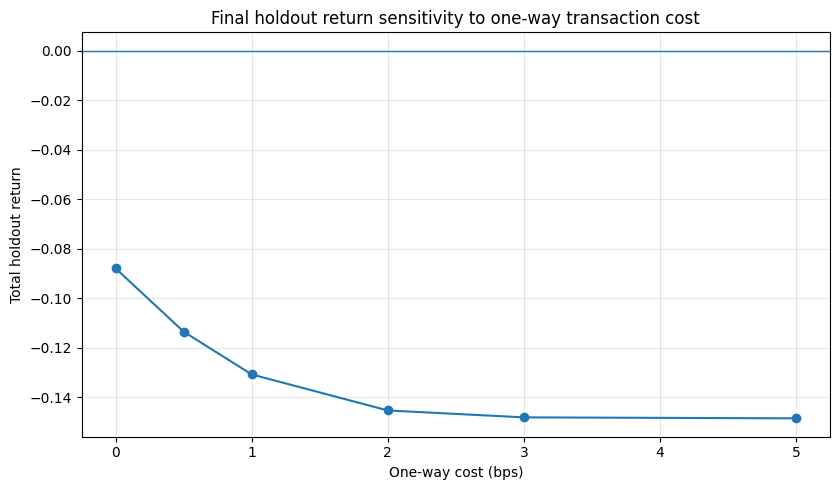

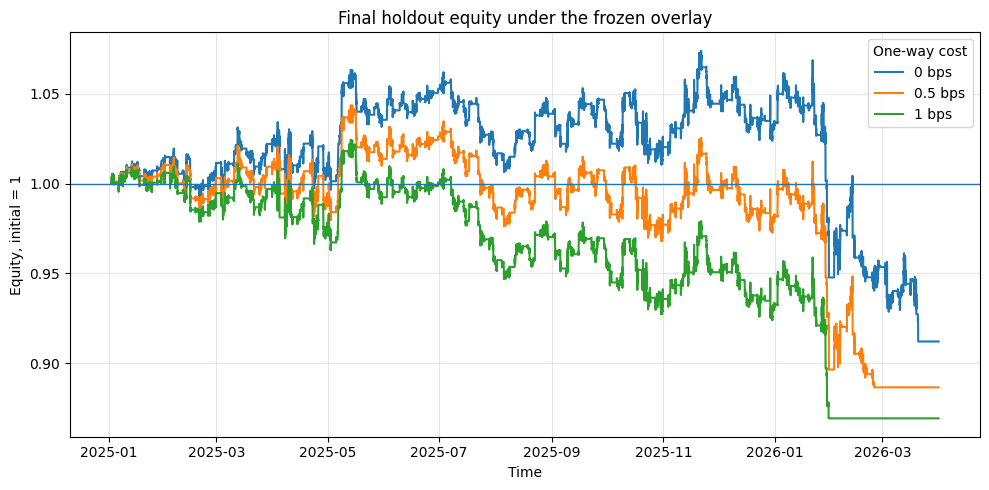

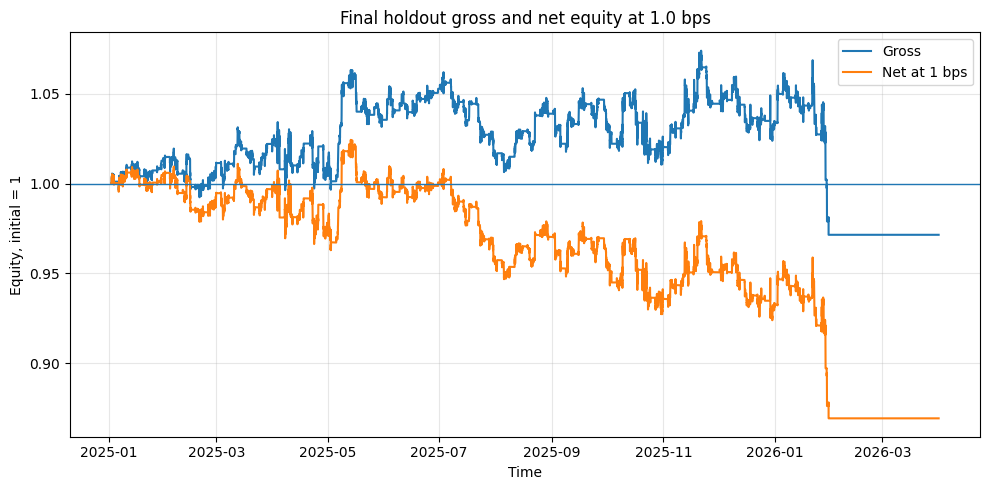

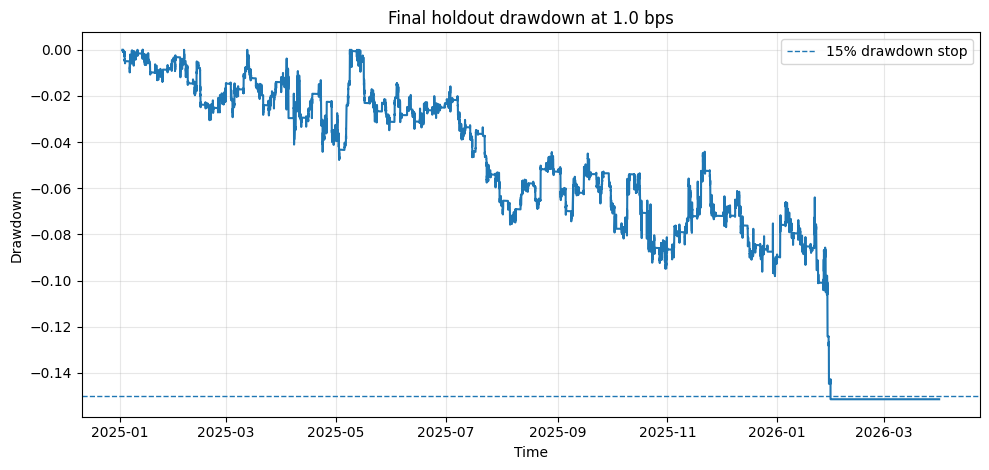

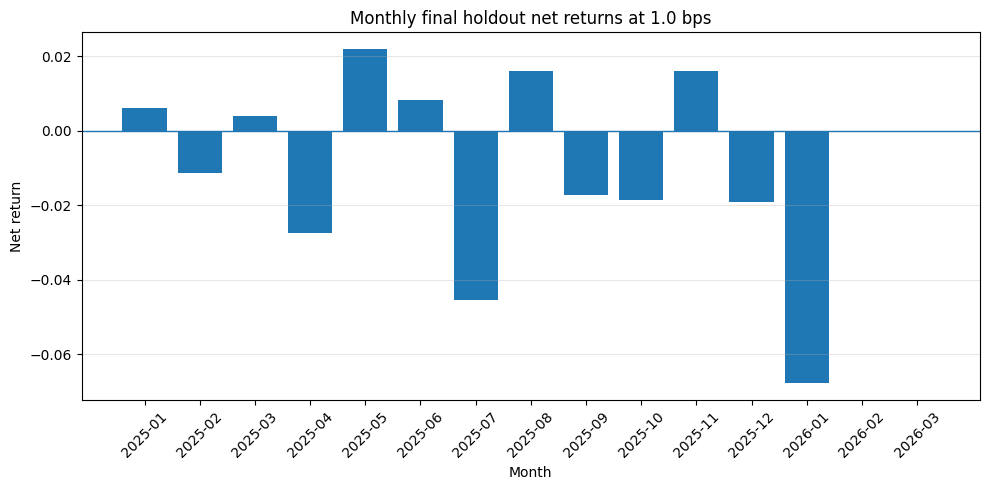

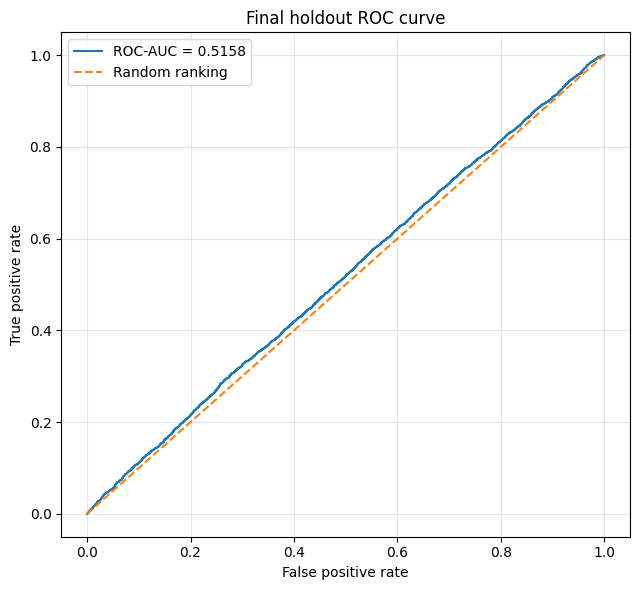

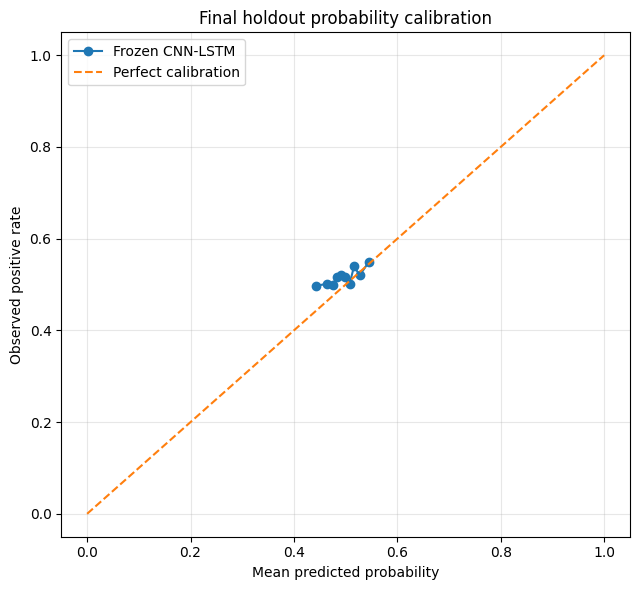

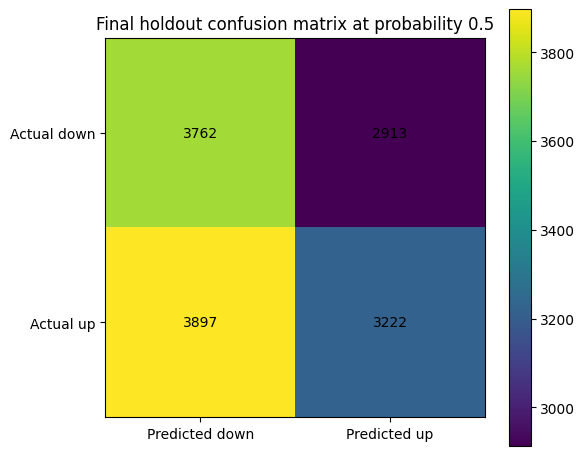

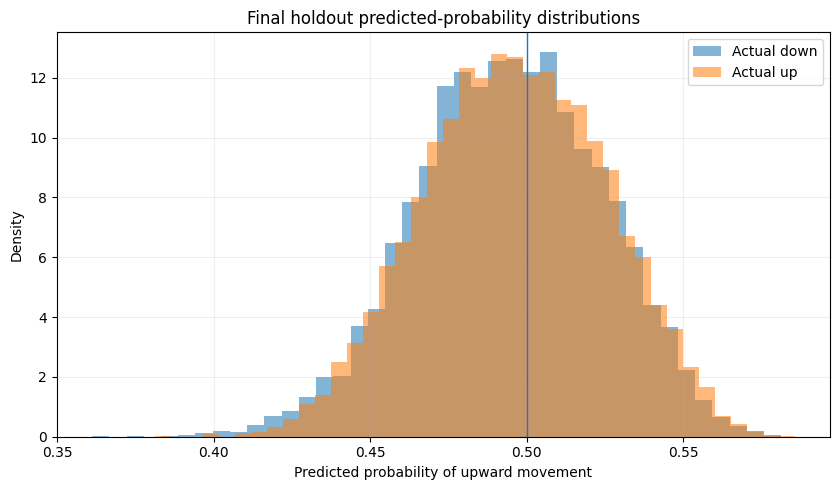

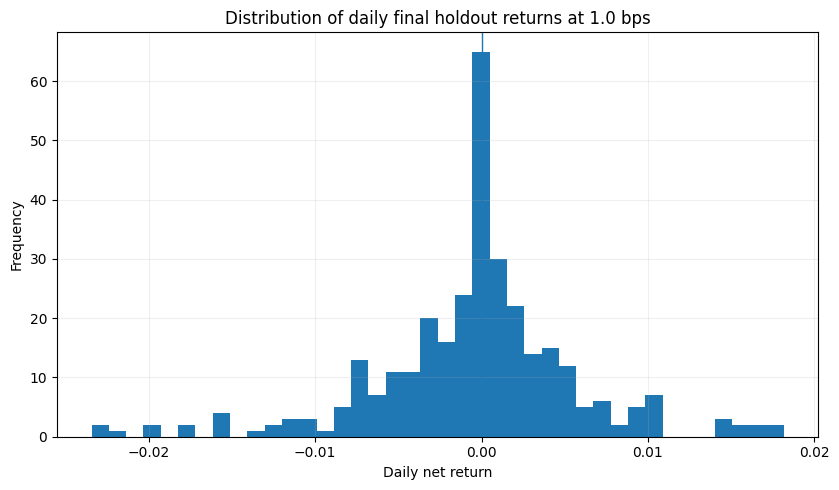

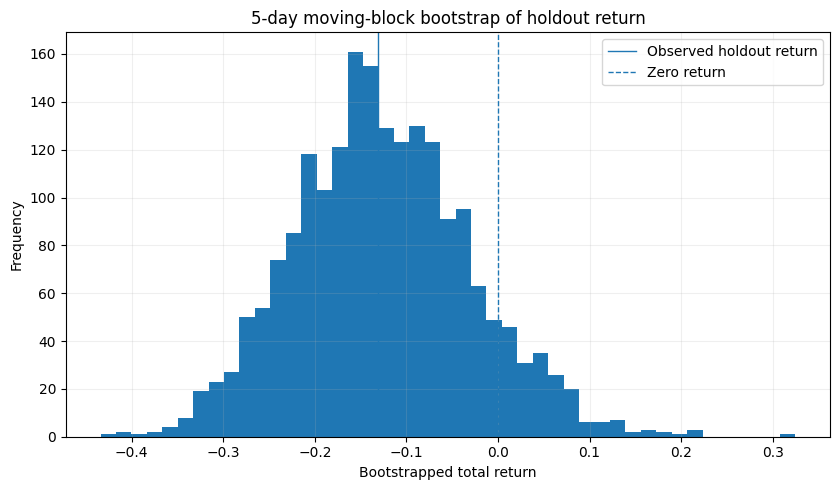

,figure,png,svg,suggested_caption
0,Cost sensitivity,figures/final_holdout_cost_sensitivity.png,figures/final_holdout_cost_sensitivity.svg,Final holdout total return under the frozen ov...
1,Equity by cost,figures/final_holdout_equity_by_cost.png,figures/final_holdout_equity_by_cost.svg,"Final holdout equity curves at 0, 0.5 and 1.0 ..."
2,Gross versus net equity,figures/final_holdout_gross_vs_net_equity_1bps...,figures/final_holdout_gross_vs_net_equity_1bps...,Difference between frictionless and cost-adjus...
3,Drawdown,figures/final_holdout_drawdown_1bps.png,figures/final_holdout_drawdown_1bps.svg,Final holdout drawdown path at the main 1.0 bp...
4,Monthly returns,figures/final_holdout_monthly_returns_1bps.png,figures/final_holdout_monthly_returns_1bps.svg,Monthly cost-adjusted returns during the final...
5,ROC curve,figures/final_holdout_roc_curve.png,figures/final_holdout_roc_curve.svg,Directional ranking performance of the frozen ...
6,Calibration curve,figures/final_holdout_calibration_curve.png,figures/final_holdout_calibration_curve.svg,Calibration of upward-direction probabilities ...
7,Confusion matrix,figures/final_holdout_confusion_matrix.png,figures/final_holdout_confusion_matrix.svg,Final holdout classification counts using the ...
8,Probability distributions,figures/final_holdout_probability_distribution...,figures/final_holdout_probability_distribution...,Distribution of predicted upward probabilities...
9,Daily return distribution,figures/final_holdout_daily_return_distributio...,figures/final_holdout_daily_return_distributio...,Distribution of daily cost-adjusted returns on...


In [13]:
def save_figure(fig: plt.Figure, filename_stem: str) -> tuple[str, str]:
    png_path = FIGURE_DIR / f'{filename_stem}.png'
    svg_path = FIGURE_DIR / f'{filename_stem}.svg'
    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(svg_path, bbox_inches='tight')
    plt.show()
    return str(png_path.relative_to(OUTPUT_DIR)), str(svg_path.relative_to(OUTPUT_DIR))

figure_index = []

# 1. Cost sensitivity
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(trading_summary['cost_bps'], trading_summary['net_return'], marker='o', label='Net return')
ax.axhline(0, linewidth=1)
ax.set_title('Final holdout return sensitivity to one-way transaction cost')
ax.set_xlabel('One-way cost (bps)')
ax.set_ylabel('Total holdout return')
ax.grid(alpha=0.3)
png, svg = save_figure(fig, 'final_holdout_cost_sensitivity')
figure_index.append({'figure': 'Cost sensitivity', 'png': png, 'svg': svg, 'suggested_caption': 'Final holdout total return under the frozen overlay across predeclared one-way transaction-cost assumptions.'})

# 2. Equity curves at 0, 0.5 and 1 bps
fig, ax = plt.subplots(figsize=(10, 5))
for cost in [0.0, 0.5, 1.0]:
    log = bar_logs[cost]
    ax.plot(pd.to_datetime(log['time'], utc=True), log['net_equity'], label=f'{cost:g} bps')
ax.axhline(1.0, linewidth=1)
ax.set_title('Final holdout equity under the frozen overlay')
ax.set_xlabel('Time')
ax.set_ylabel('Equity, initial = 1')
ax.grid(alpha=0.3)
ax.legend(title='One-way cost')
png, svg = save_figure(fig, 'final_holdout_equity_by_cost')
figure_index.append({'figure': 'Equity by cost', 'png': png, 'svg': svg, 'suggested_caption': 'Final holdout equity curves at 0, 0.5 and 1.0 bps one-way cost.'})

# 3. Gross versus net equity at main cost
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pd.to_datetime(main_bar_log['time'], utc=True), main_bar_log['gross_equity'], label='Gross')
ax.plot(pd.to_datetime(main_bar_log['time'], utc=True), main_bar_log['net_equity'], label='Net at 1 bps')
ax.axhline(1.0, linewidth=1)
ax.set_title('Final holdout gross and net equity at 1.0 bps')
ax.set_xlabel('Time')
ax.set_ylabel('Equity, initial = 1')
ax.grid(alpha=0.3)
ax.legend()
png, svg = save_figure(fig, 'final_holdout_gross_vs_net_equity_1bps')
figure_index.append({'figure': 'Gross versus net equity', 'png': png, 'svg': svg, 'suggested_caption': 'Difference between frictionless and cost-adjusted final holdout equity under the frozen strategy.'})

# 4. Drawdown
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(pd.to_datetime(main_bar_log['time'], utc=True), main_bar_log['drawdown'])
ax.axhline(TOTAL_DRAWDOWN_STOP, linestyle='--', linewidth=1, label='15% drawdown stop')
ax.set_title('Final holdout drawdown at 1.0 bps')
ax.set_xlabel('Time')
ax.set_ylabel('Drawdown')
ax.grid(alpha=0.3)
ax.legend()
png, svg = save_figure(fig, 'final_holdout_drawdown_1bps')
figure_index.append({'figure': 'Drawdown', 'png': png, 'svg': svg, 'suggested_caption': 'Final holdout drawdown path at the main 1.0 bps cost assumption.'})

# 5. Monthly returns
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly['month'], monthly['net_return'])
ax.axhline(0, linewidth=1)
ax.set_title('Monthly final holdout net returns at 1.0 bps')
ax.set_xlabel('Month')
ax.set_ylabel('Net return')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
png, svg = save_figure(fig, 'final_holdout_monthly_returns_1bps')
figure_index.append({'figure': 'Monthly returns', 'png': png, 'svg': svg, 'suggested_caption': 'Monthly cost-adjusted returns during the final untouched holdout.'})

# 6. ROC
fpr, tpr, _ = roc_curve(holdout_predictions['target_dir'], holdout_predictions['p_up'])
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, label=f"ROC-AUC = {holdout_classification['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle='--', label='Random ranking')
ax.set_title('Final holdout ROC curve')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.grid(alpha=0.3)
ax.legend()
png, svg = save_figure(fig, 'final_holdout_roc_curve')
figure_index.append({'figure': 'ROC curve', 'png': png, 'svg': svg, 'suggested_caption': 'Directional ranking performance of the frozen CNN-LSTM on the final untouched holdout.'})

# 7. Calibration
prob_true, prob_pred = calibration_curve(
    holdout_predictions['target_dir'], holdout_predictions['p_up'], n_bins=10, strategy='quantile'
)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(prob_pred, prob_true, marker='o', label='Frozen CNN-LSTM')
ax.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
ax.set_title('Final holdout probability calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed positive rate')
ax.grid(alpha=0.3)
ax.legend()
png, svg = save_figure(fig, 'final_holdout_calibration_curve')
figure_index.append({'figure': 'Calibration curve', 'png': png, 'svg': svg, 'suggested_caption': 'Calibration of upward-direction probabilities on the final untouched holdout.'})

# 8. Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center')
ax.set_xticks([0, 1], labels=['Predicted down', 'Predicted up'])
ax.set_yticks([0, 1], labels=['Actual down', 'Actual up'])
ax.set_title('Final holdout confusion matrix at probability 0.5')
fig.colorbar(im, ax=ax)
png, svg = save_figure(fig, 'final_holdout_confusion_matrix')
figure_index.append({'figure': 'Confusion matrix', 'png': png, 'svg': svg, 'suggested_caption': 'Final holdout classification counts using the conventional 0.5 probability threshold.'})

# 9. Probability distribution by realised class
fig, ax = plt.subplots(figsize=(8.5, 5))
for cls, label in [(0, 'Actual down'), (1, 'Actual up')]:
    vals = holdout_predictions.loc[holdout_predictions['target_dir'] == cls, 'p_up']
    ax.hist(vals, bins=40, alpha=0.55, density=True, label=label)
ax.axvline(0.5, linewidth=1)
ax.set_title('Final holdout predicted-probability distributions')
ax.set_xlabel('Predicted probability of upward movement')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.2)
png, svg = save_figure(fig, 'final_holdout_probability_distribution_by_class')
figure_index.append({'figure': 'Probability distributions', 'png': png, 'svg': svg, 'suggested_caption': 'Distribution of predicted upward probabilities by realised next-bar direction.'})

# 10. Daily return distribution
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(daily['net_return'], bins=40)
ax.axvline(0, linewidth=1)
ax.set_title('Distribution of daily final holdout returns at 1.0 bps')
ax.set_xlabel('Daily net return')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.2)
png, svg = save_figure(fig, 'final_holdout_daily_return_distribution_1bps')
figure_index.append({'figure': 'Daily return distribution', 'png': png, 'svg': svg, 'suggested_caption': 'Distribution of daily cost-adjusted returns on the final untouched holdout.'})

# 11. Primary bootstrap distribution
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(primary_bootstrap['total_return'], bins=45)
ax.axvline(main_metrics['net_return'], linewidth=1, label='Observed holdout return')
ax.axvline(0, linestyle='--', linewidth=1, label='Zero return')
ax.set_title(f'{PRIMARY_BOOTSTRAP_BLOCK_DAYS}-day moving-block bootstrap of holdout return')
ax.set_xlabel('Bootstrapped total return')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.2)
png, svg = save_figure(fig, 'final_holdout_block_bootstrap_total_return')
figure_index.append({'figure': 'Block-bootstrap return distribution', 'png': png, 'svg': svg, 'suggested_caption': 'Moving-block bootstrap distribution of total final holdout return using daily return blocks.'})

figure_index_df = pd.DataFrame(figure_index)
figure_index_df.to_csv(TABLE_DIR / 'report_figure_index.csv', index=False)
display(figure_index_df)


## Interpretation rules

- A positive holdout result is evidence limited to this single frozen evaluation period; it is not proof of long-term profitability.
- A negative result must be reported without changing the model or rerunning another candidate.
- A stay-flat result means the 2024 validation gate did not support trading. It is a valid final outcome.
- Bootstrap intervals describe uncertainty conditional on the observed holdout return process and chosen block lengths. They do not create new independent market histories.
- Deployment engineering may continue after this result, but the paper-trading artefact must be labelled separately from the holdout-evaluation artefact.


In [14]:
# Final findings, artefact manifest, and one-shot completion lock
main_metrics = trading_summary.loc[trading_summary['cost_bps'] == MAIN_SELECTION_COST_BPS].iloc[0]
primary_bootstrap_summary = bootstrap_summary.loc[
    bootstrap_summary['block_length_days'] == PRIMARY_BOOTSTRAP_BLOCK_DAYS
].iloc[0]

findings_lines = [
    'Notebook 7 — Final untouched holdout evaluation findings draft',
    '=' * 84,
    '',
    'Frozen candidate: CNN-LSTM vanilla volume-assisted, M15.',
    f"Final overlay action selected on 2024: {selected_overlay['selected_action']}.",
    f"Final holdout period: {holdout_predictions['time'].min()} to {holdout_predictions['time'].max()}.",
    '',
    'Classification:',
    f"- ROC-AUC: {holdout_classification['roc_auc']:.6f}",
    f"- Balanced accuracy: {holdout_classification['balanced_accuracy']:.6f}",
    f"- Brier improvement versus prevalence baseline: {holdout_classification['brier_improvement_vs_baseline']:.6f}",
    '',
    'Trading at the main 1.0 bps one-way cost:',
    f"- Net return: {main_metrics['net_return']:.6f}",
    f"- Gross return: {main_metrics['gross_return']:.6f}",
    f"- Sharpe: {main_metrics['sharpe']:.6f}",
    f"- Sortino: {main_metrics['sortino']:.6f}",
    f"- Maximum drawdown: {main_metrics['max_drawdown']:.6f}",
    f"- Trade count: {int(main_metrics['trade_count'])}",
    f"- Active rate: {main_metrics['active_rate']:.6f}",
    f"- Total drawdown stop triggered: {bool(main_metrics['total_drawdown_stop_triggered'])}",
    '',
    'Block-bootstrap uncertainty:',
    f"- Primary block length: {PRIMARY_BOOTSTRAP_BLOCK_DAYS} days",
    f"- 95% total-return interval: [{primary_bootstrap_summary['total_return_p2_5']:.6f}, {primary_bootstrap_summary['total_return_p97_5']:.6f}]",
    f"- Bootstrap probability of positive total return: {primary_bootstrap_summary['probability_total_return_positive']:.4f}",
    '',
    f'Predeclared final status: {holdout_status}.',
    '',
    'Research-integrity statement:',
    '- No architecture, feature, overlay-grid, risk-control, or cost assumption was changed after the holdout was opened.',
    '- The candidate cannot be replaced after observing this result.',
    '- Any production refit for MT5 paper trading is a separate deployment artefact, not another holdout test.',
]
findings_path = OUTPUT_DIR / 'final_holdout_findings_draft.txt'
findings_path.write_text('\n'.join(findings_lines), encoding='utf-8')

artefact_paths = [
    FINAL_MODEL_PATH,
    FINAL_SCALER_PATH,
    FINAL_FEATURES_PATH,
    FINAL_PARAMS_PATH,
    SELECTED_EPOCH_PATH,
    SELECTED_OVERLAY_PATH,
    VALIDATION_PREDICTIONS_PATH,
    HOLDOUT_PREDICTIONS_PATH,
    TABLE_DIR / 'final_holdout_trading_metrics_by_cost.csv',
    TABLE_DIR / 'final_holdout_classification_metrics.csv',
    TABLE_DIR / 'final_holdout_strategy_bar_log_1bps.csv',
    findings_path,
]
missing = [str(path) for path in artefact_paths if not path.exists()]
if missing:
    raise RuntimeError(f'Cannot complete Notebook 7 because required artefacts are missing: {missing}')

artefact_manifest = {
    'notebook_config_version': NOTEBOOK_CONFIG_VERSION,
    'config_fingerprint': config_fingerprint,
    'candidate': EXPECTED_CANDIDATE,
    'frozen_params': EXPECTED_FROZEN_PARAMS,
    'selected_epoch': selected_epoch,
    'selected_overlay': selected_overlay,
    'holdout_status': holdout_status,
    'holdout_start': holdout_predictions['time'].min(),
    'holdout_end': holdout_predictions['time'].max(),
    'holdout_prediction_rows': len(holdout_predictions),
    'main_cost_bps': MAIN_SELECTION_COST_BPS,
    'main_cost_metrics': main_metrics.to_dict(),
    'candidate_manifest_source_sha256': sha256_file(CANDIDATE_MANIFEST_PATH),
    'artefacts': {
        str(path.relative_to(OUTPUT_DIR)): sha256_file(path)
        for path in artefact_paths
    },
}
atomic_write_json(CONFIG_DIR / 'evaluation_artefact_manifest.json', artefact_manifest)

if not COMPLETION_LOCK_PATH.exists():
    atomic_write_json(COMPLETION_LOCK_PATH, {
        'status': 'COMPLETE_AND_LOCKED',
        'completed_utc': pd.Timestamp.now(tz='UTC'),
        'config_fingerprint': config_fingerprint,
        'holdout_status': holdout_status,
        'holdout_predictions_sha256': sha256_file(HOLDOUT_PREDICTIONS_PATH),
        'evaluation_manifest_sha256': sha256_file(CONFIG_DIR / 'evaluation_artefact_manifest.json'),
        'instruction': 'Do not change the frozen methodology or create a second holdout attempt.',
    })

print(findings_path.read_text(encoding='utf-8'))
print('\nCompletion lock:', COMPLETION_LOCK_PATH)


Notebook 7 — Final untouched holdout evaluation findings draft

Frozen candidate: CNN-LSTM vanilla volume-assisted, M15.
Final overlay action selected on 2024: trade.
Final holdout period: 2025-01-02 11:00:00+00:00 to 2026-03-31 20:45:00+00:00.

Classification:
- ROC-AUC: 0.515827
- Balanced accuracy: 0.508094
- Brier improvement versus prevalence baseline: -0.000028

Trading at the main 1.0 bps one-way cost:
- Net return: -0.130768
- Gross return: -0.028530
- Sharpe: -1.558425
- Sortino: -1.514594
- Maximum drawdown: -0.151437
- Trade count: 556
- Active rate: 0.583950
- Total drawdown stop triggered: True

Block-bootstrap uncertainty:
- Primary block length: 5 days
- 95% total-return interval: [-0.304951, 0.071788]
- Bootstrap probability of positive total return: 0.1010

Predeclared final status: NEGATIVE.

Research-integrity statement:
- No architecture, feature, overlay-grid, risk-control, or cost assumption was changed after the holdout was opened.
- The candidate cannot be repla

In [15]:
print('Notebook 7 output inventory')
print('=' * 60)
for label, directory in [
    ('Tables', TABLE_DIR),
    ('Figures', FIGURE_DIR),
    ('Models', MODEL_DIR),
    ('Preprocessing', PREPROCESS_DIR),
    ('Configuration', CONFIG_DIR),
    ('Training histories', HISTORY_DIR),
]:
    print(f'\n{label}:')
    for path in sorted(directory.glob('*')):
        if path.is_file():
            print(' -', path.relative_to(OUTPUT_DIR))
print('\nFindings:')
print(' -', (OUTPUT_DIR / 'final_holdout_findings_draft.txt').relative_to(OUTPUT_DIR))


Notebook 7 output inventory

Tables:
 - tables/candidate_freeze_audit.csv
 - tables/final_holdout_block_bootstrap_replicates_primary.csv
 - tables/final_holdout_block_bootstrap_summary.csv
 - tables/final_holdout_classification_metrics.csv
 - tables/final_holdout_confusion_matrix.csv
 - tables/final_holdout_daily_returns_1bps.csv
 - tables/final_holdout_monthly_returns_1bps.csv
 - tables/final_holdout_position_change_events_1bps.csv
 - tables/final_holdout_predictions.csv
 - tables/final_holdout_status.csv
 - tables/final_holdout_strategy_bar_log_1bps.csv
 - tables/final_holdout_trading_metrics_by_cost.csv
 - tables/final_temporal_partition_rows.csv
 - tables/overlay_validation_classification_metrics.csv
 - tables/overlay_validation_grid_at_1bps.csv
 - tables/overlay_validation_predictions.csv
 - tables/report_figure_index.csv
 - tables/selected_final_overlay.csv

Figures:
 - figures/final_holdout_block_bootstrap_total_return.png
 - figures/final_holdout_block_bootstrap_total_return.sv